# Prediction de la Satisfaction des Passagers Aériens

 ## Contexte de l’étude :

Le contexte de ce projet est de guider une compagnie aérienne pour déterminer les facteurs importants qui influencent la satisfaction du client. La satisfaction du client joue un rôle majeur dans l’activité d’une entreprise. C’est pourquoi l’analyse et l’amélioration des facteurs étroitement liés à la satisfaction du client sont importantes pour la croissance et la réputation d’une entreprise.

## Problème
- Afin d'améliorer les services aériens et la satisfaction des passagers, il est important d'analyser le niveau de satisfaction des passagers aériens et de prédire leur satisfaction.

- Ce problème relève de la catégorie des problèmes de classification, où nous devons prédire si les passagers aériens sont satisfaits, neutres ou insatisfaits.

## Solution :

- La visualisation des données et le nettoyage du jeu de données pour comprendre les données et les préparer pour le processus ultérieur
- Déterminer quelles variables ont un impact significatif sur la satisfaction des passagers
- Analyse des erreurs
- Entraîner le modèle de classification
- Effectuer des prédictions
- Évaluation du modèle
- Des hyperparamètres et Processus de sélection de variables
- Conclusion

Le jeu de données qui sera étudier est en accès libre et a été téléchargé via Kaggle. Il se compose de deux fichiers :
- Un jeu de données d’entraînement (*training set*) contenant 103 904 lignes et 25 variables
- Un jeu de données de test (*testing set*) contenant lignes et 25 976 lignes et 25 variables 

 Le dataset contient :
- 4 variables numériques qui sont : 'Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes'
- 4 variables catégorielles : 'Gender', 'Customer Type', 'Type of Travel', Type de classe’
- 15 variables ordinales et concernent tous les services proposés par la compagnie aérienne durant le voyage et notés sur une échelle de 0 à 5.

### Chargement des packages

In [1]:
import numpy as np
import sys
np.set_printoptions(threshold=sys.maxsize)
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


import numpy as np                       
import pandas as pd                     
import seaborn as sns                  
import matplotlib.pyplot as plt         
import scipy                           
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC 
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score





################## DJIAVOUDINE
################## Quthbulhameed 
################## M2 I2A

**Importer	ce	jeu	de	données**

In [2]:
test_df = pd.read_csv("Airline_Passengers/test.csv")
train_df = pd.read_csv("Airline_Passengers/train.csv")


********Visualisation des premières lignes (Base d'entraînement)********


In [3]:
train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [5]:
# print(train_df['Gender'].value_counts())
# print("---------------------------------------\n")

# print(train_df['Customer Type'].value_counts())
# print("---------------------------------------\n")

# print(train_df['Type of Travel'].value_counts())
# print("---------------------------------------\n")

# print(train_df['Class'].value_counts())
# print("---------------------------------------\n")


# print(train_df['satisfaction'].value_counts())
# print("---------------------------------------\n")









# Partie I : Analyse descriptive

## Analyse de la variable à expliquer (target)

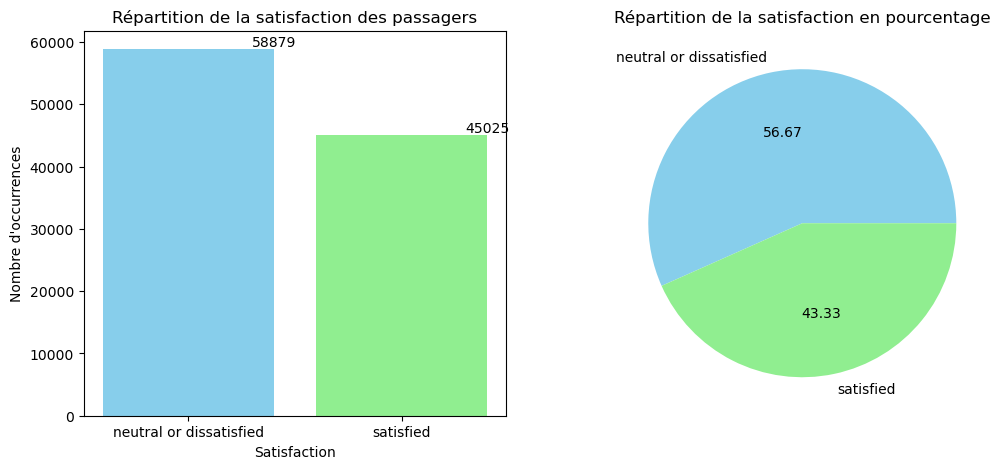

In [6]:

color = ['skyblue', 'lightgreen']


fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))


bars = ax1.bar(train_df['satisfaction'].value_counts().index, train_df['satisfaction'].value_counts(), color=color)
ax1.set_xlabel('Satisfaction')
ax1.set_ylabel('Nombre d\'occurrences')
ax1.set_title('Répartition de la satisfaction des passagers')

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width(), yval, round(yval, 2), ha='center', va='bottom')

ax2.pie(train_df['satisfaction'].value_counts(), labels=['neutral or dissatisfied', 'satisfied'], autopct="%0.2f",colors =color)
ax2.set_title('Répartition de la satisfaction en pourcentage')


# Afficher la figure
plt.show()


- Environ 56% des clients ont exprimé un avis neutre ou une insatisfaction.
- 43% des passagers sont satisfaits des services.
- La répartition montre que les classes sont plus ou moins équilibrées.

## Analyse des features

In [7]:
print("Columns name")
for i, column in enumerate(train_df.columns, 1):
    print(f"{i}\t{column}")



Columns name
1	Unnamed: 0
2	id
3	Gender
4	Customer Type
5	Age
6	Type of Travel
7	Class
8	Flight Distance
9	Inflight wifi service
10	Departure/Arrival time convenient
11	Ease of Online booking
12	Gate location
13	Food and drink
14	Online boarding
15	Seat comfort
16	Inflight entertainment
17	On-board service
18	Leg room service
19	Baggage handling
20	Checkin service
21	Inflight service
22	Cleanliness
23	Departure Delay in Minutes
24	Arrival Delay in Minutes
25	satisfaction


### La majorité des variables présentes dans le jeu de données sont de types catégorielles ou ordinales.

###### on choisira donc la définition de 3 types de variables définies comme suit :

- **Variables numériques** : age,flight distance, departure delay in minutes, arrival delay in minutes
- **Variables catégorielles** : gender, customer type, type of travel
- **Variables ordinales** : class, inflight wifi service, departure/arrival time convenient, ease  of online booking,gate location, food and drink, online boarding, seat comfort, inflight entertainment, on-board service, leg room service,baggage handling, checkin service, inflight service, cleanliness

# _________________________________________________________________

## Variables catégorielles (Categorical : Nominal)

### Certaines caractéristiques sont nominales : sexe, type de client, type de voyage, classe.

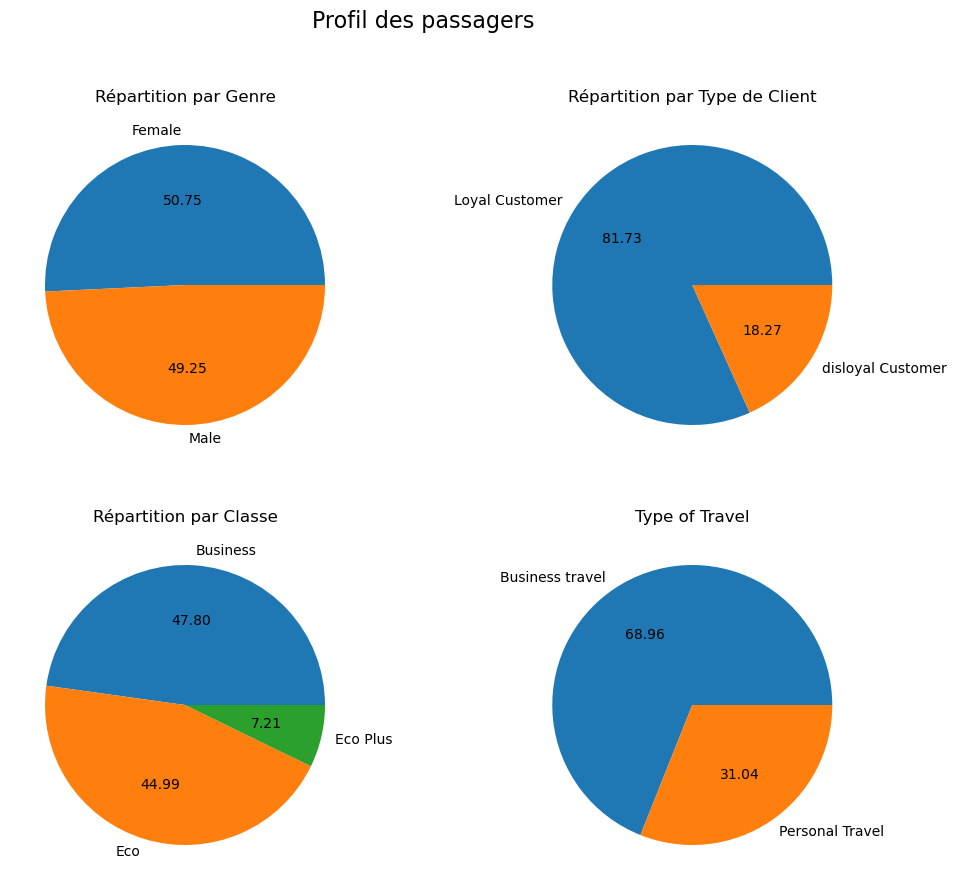

In [8]:

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

ax1.pie(train_df['Gender'].value_counts(), labels=train_df['Gender'].value_counts().index, autopct="%0.2f")
ax1.set_title('Répartition par Genre')

ax2.pie(train_df['Customer Type'].value_counts(), labels=train_df['Customer Type'].value_counts().index, autopct="%0.2f")
ax2.set_title('Répartition par Type de Client')

ax3.pie(train_df['Class'].value_counts(), labels=train_df['Class'].value_counts().index, autopct="%0.2f")
ax3.set_title('Répartition par Classe')

ax4.pie(train_df['Type of Travel'].value_counts(), labels=train_df['Type of Travel'].value_counts().index, autopct="%0.2f")
ax4.set_title('Type of Travel')


fig.suptitle('Profil des passagers', fontsize=16)

plt.show()


- La proportion d'Homme/Femme est équilibrée
- La majorité des clients de la compagnie sont des clients habituels
- Près de 7 voyages sur 10 concernent des déplacements pour raisons professionnelles plutôt que personnelles
- 48% des passagers voyagent en classe buisiness et 45% en Eco

# _________________________________________________________________

### Analyse Variables catégorielles Avec target (satisfaction)


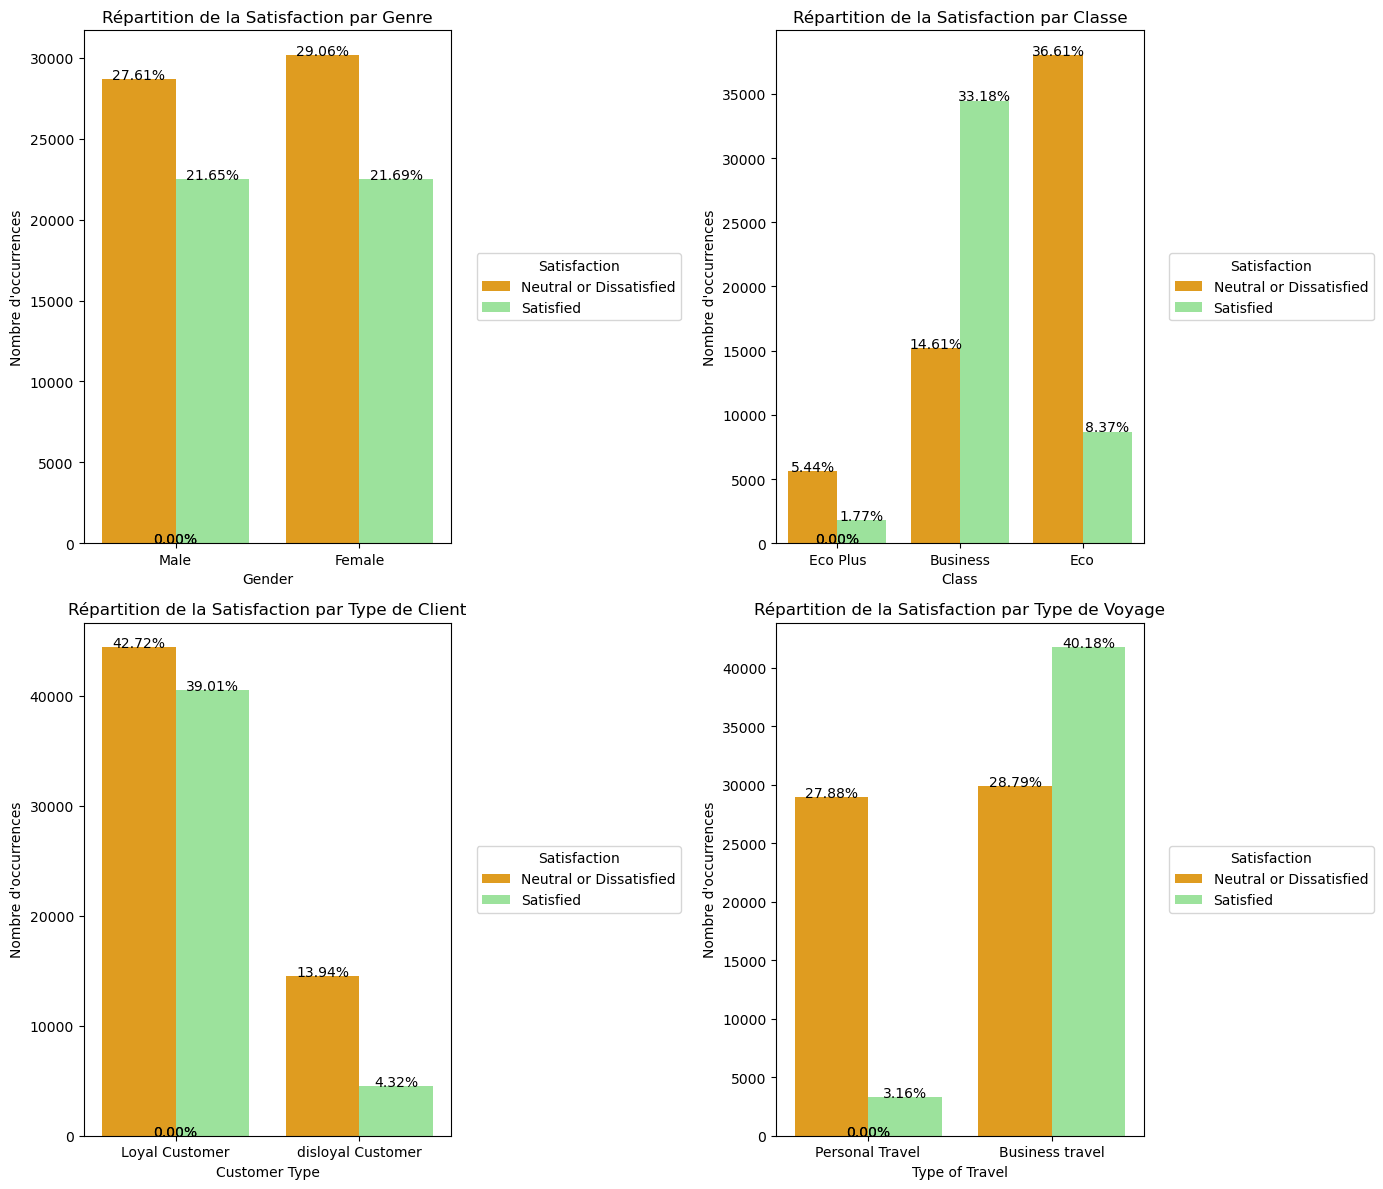

In [9]:

def plot_satisfaction_by_column(column_name, title, ax):
    sns.countplot(x=column_name, hue='satisfaction', data=train_df, palette=['orange', 'lightgreen'], ax=ax)

    ax.set_xlabel(column_name)
    ax.set_ylabel('Nombre d\'occurrences')
    ax.set_title(f'Répartition de la Satisfaction par {title}')

    ax.legend(title='Satisfaction', bbox_to_anchor=(1.05, 0.5), loc='center left', labels=['Neutral or Dissatisfied', 'Satisfied'])

    total = len(train_df[column_name])
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 3,
                f'{(height / total * 100):.2f}%',
                ha="center")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

plot_satisfaction_by_column('Gender', 'Genre', ax1)
plot_satisfaction_by_column('Class', 'Classe', ax2)
plot_satisfaction_by_column('Customer Type', 'Type de Client', ax3)
plot_satisfaction_by_column('Type of Travel', 'Type de Voyage', ax4)

plt.tight_layout()

plt.show()


**Remarques Générales :** <br>
- Proportion équilibrée entre les clients satisfaits/insatisfaits et ce quelque soit le genre (homme ou femme)
- Les clients qui ont voyagé en classe Economique et Economique Plus sont les plus insatisfaits de leur voyage en comparaison avec ceux qui ont voyagé en classe Business **avec près de 49 points d'écart** (**% d'insatisfaction estimée à 74.2 versus 25.8**)
- Les clients qui voyagent pour des raisons professionnelles sont plus satisfaits 
- Les clients réguliers (Loyal customer) expriment à la fois une grande satisfaction et insatisfaction

## Analyse des variables ordinales avec target (Satisfaction)

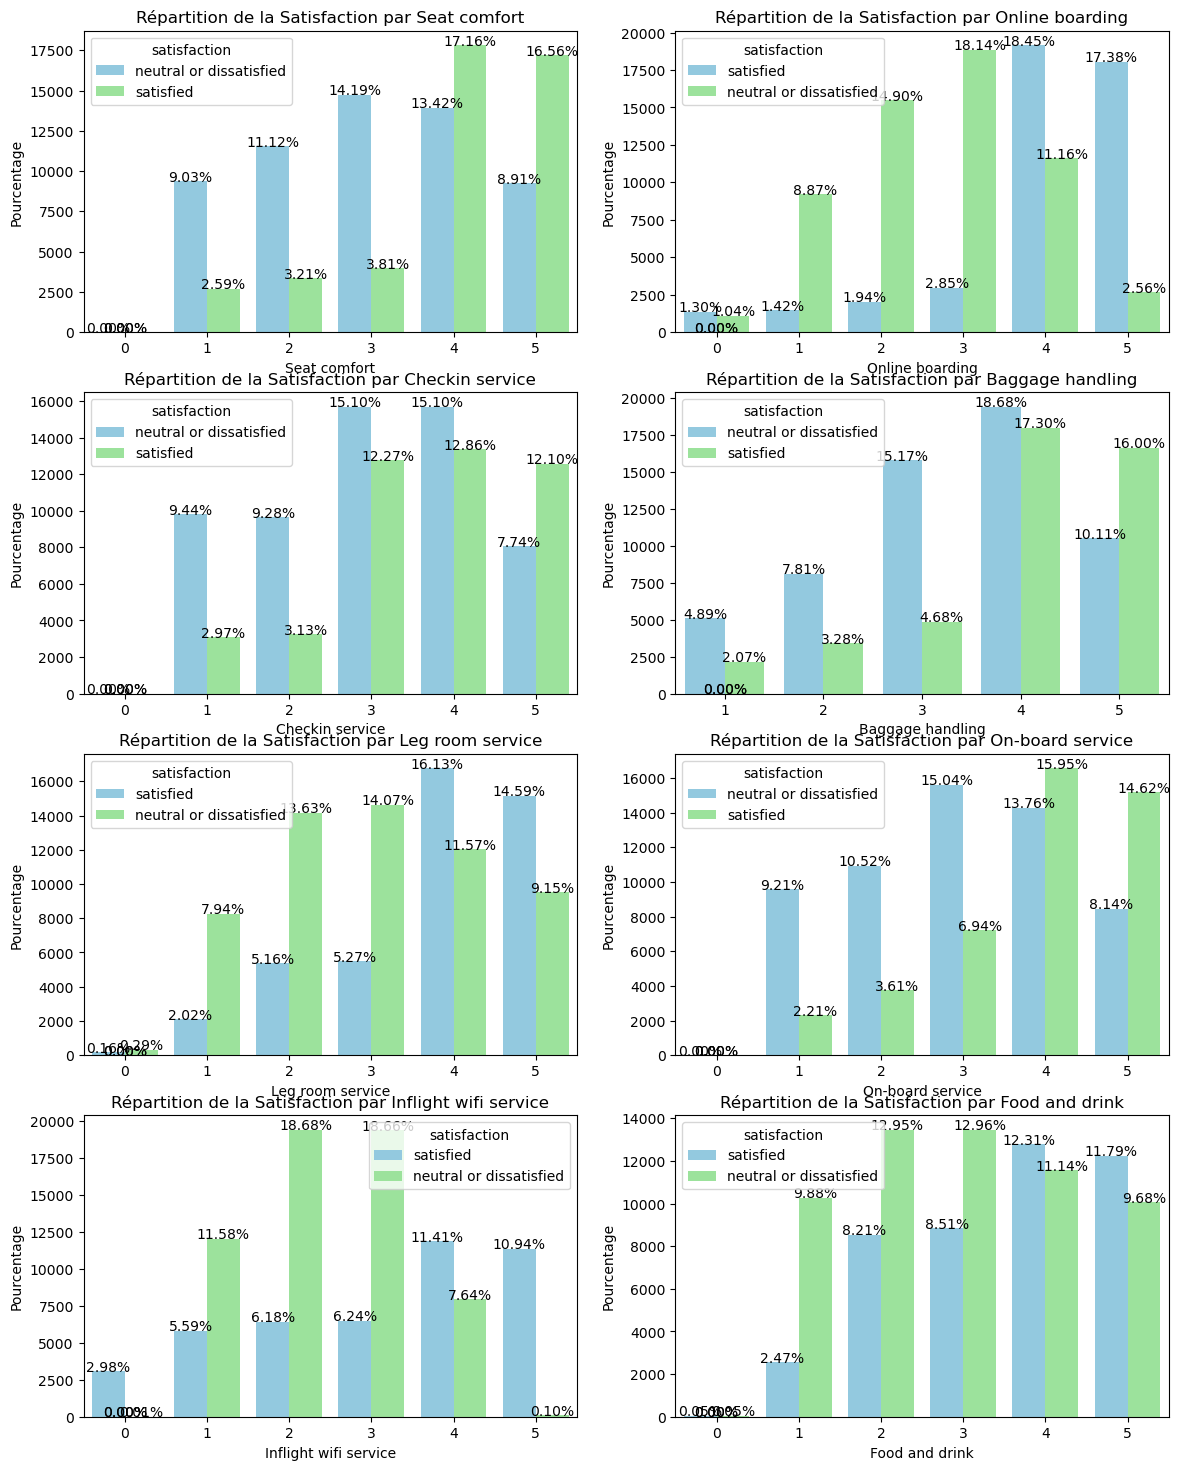

In [10]:


def plot_satisfaction(column_name, ax):
    sns.countplot(x=column_name, hue='satisfaction', data=train_df, palette=['skyblue', 'lightgreen'], ax=ax)

    ax.set_xlabel(column_name)
    ax.set_ylabel('Pourcentage')
    ax.set_title(f'Répartition de la Satisfaction par {column_name}')

    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 3,
                f'{(height / len(train_df) * 100):.2f}%',
                ha="center")

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))

plot_satisfaction('Seat comfort', ax1)
plot_satisfaction('Online boarding', ax2)
plot_satisfaction('Checkin service', ax3)
plot_satisfaction('Baggage handling', ax4)
plot_satisfaction('Leg room service', ax5)
plot_satisfaction('On-board service', ax6)
plot_satisfaction('Inflight wifi service', ax7)
plot_satisfaction('Food and drink', ax8)

plt.show()


**Concernant les services proposés par la companie:** <br>


- Plus les services proposés par la compagnie sont très bien notés (notes au moins égales à 4 étoiles), meilleure est la satisfaction du client.



## Analyse des variables numériques

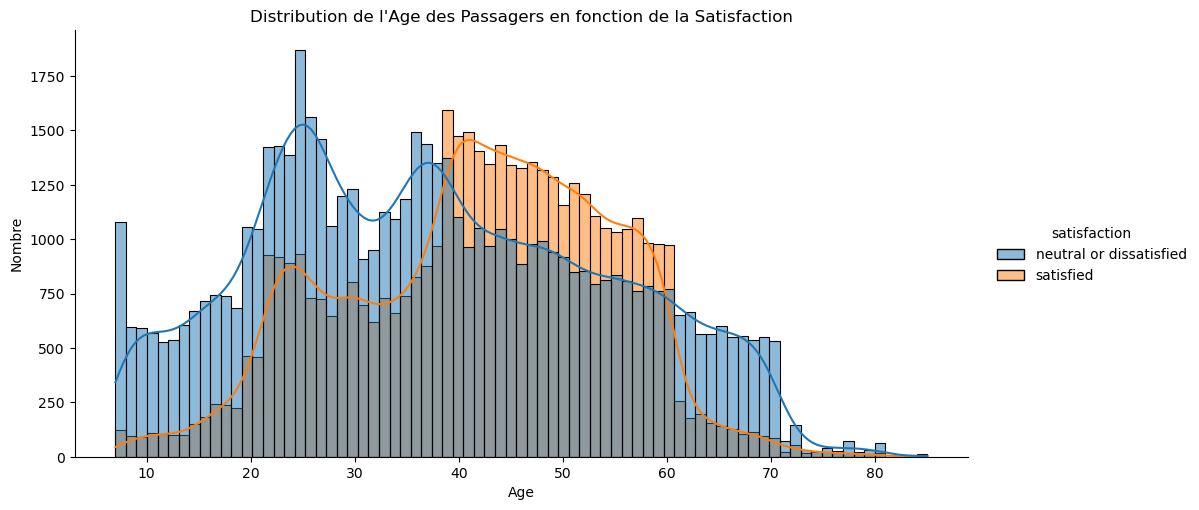

In [11]:


sns.displot(train_df, x='Age', hue='satisfaction', kde=True, aspect=2, color='slategray')

plt.title('Distribution de l\'Age des Passagers en fonction de la Satisfaction')
plt.xlabel('Age')
plt.ylabel('Nombre')

plt.show()


**Remarque** <br>
- Proportion de clients satisfaits qui s'accroient avec l'âge (moyenne des clients satisfaits estimée au alentour de 42 ans)
- Environ 21 à 36 ans étaient neutres ou insatisfaits
- environ les passagers âgés de 39 à 50 ans étaient satisfaits

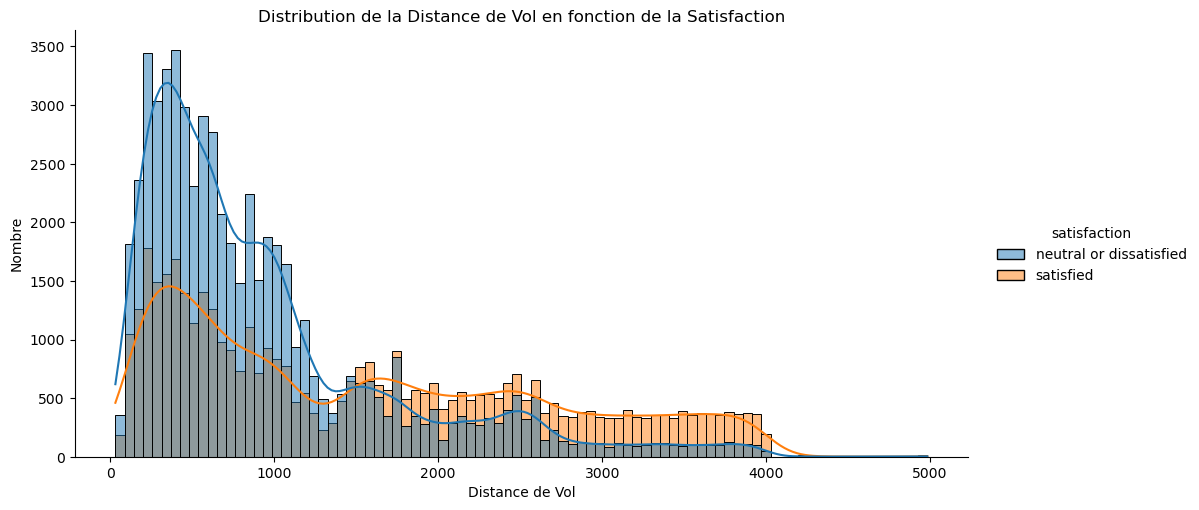

In [12]:


sns.displot(train_df, x='Flight Distance', hue='satisfaction', kde=True, aspect=2, color='slategray')

plt.title('Distribution de la Distance de Vol en fonction de la Satisfaction')
plt.xlabel('Distance de Vol')
plt.ylabel('Nombre')

plt.show()


**Remarque** <br>
- La majorité des clients insatisfaits concerne des vols courts/moyens courriers. (ci-dessous où on remarque que la majorité des clients qui voyagent en classe business concerne des voyages longs courriers).
- Les passagers ayant une longue distance de vol sont plus satisfaits

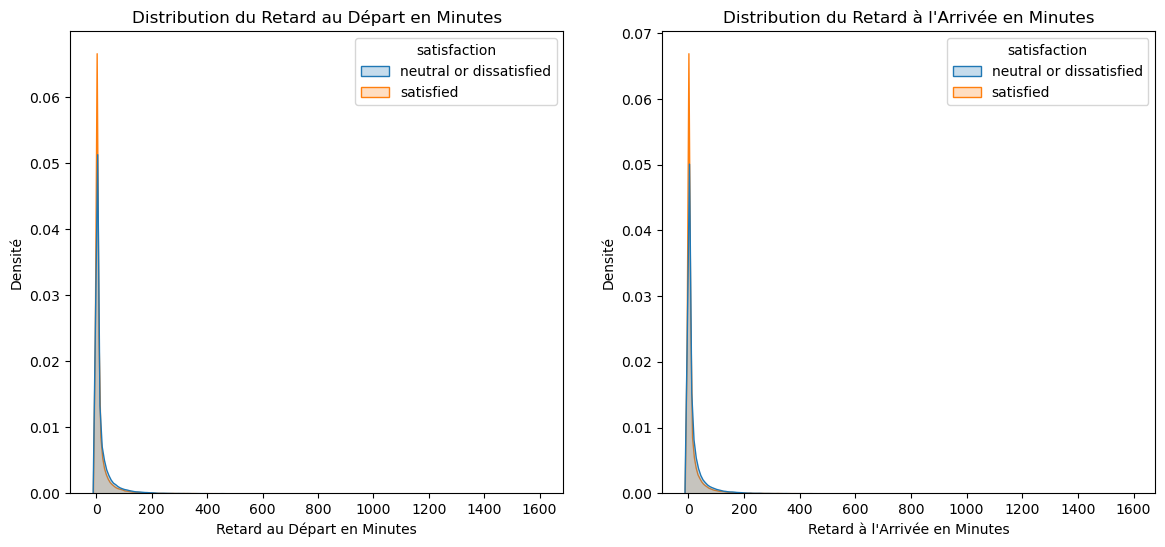

In [13]:


def plot_delay_distribution(data, column, title, xlabel, ax):
    sns.kdeplot(data=data, x=column, hue='satisfaction', fill=True, common_norm=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Densité')

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

plot_delay_distribution(train_df, 'Departure Delay in Minutes', 'Distribution du Retard au Départ en Minutes', 'Retard au Départ en Minutes', ax1)
plot_delay_distribution(train_df, 'Arrival Delay in Minutes', 'Distribution du Retard à l\'Arrivée en Minutes', 'Retard à l\'Arrivée en Minutes', ax2)

plt.show()


**Remarque** <br>
- En ce qui concerne les retards enregistrés au départ et à l'arrivée, l'histogramme ne permet pas à première vue de savoir si une réelle différence existe entre la satisfaction et l'insatisfaction. (cf.tableau plot ci-dessous).
- Le retard maximum de départ et le retard d'arrivée sont d'environ 0 à 10 minutes.
- On peut dire que la plupart du temps il n'y a pas de retard

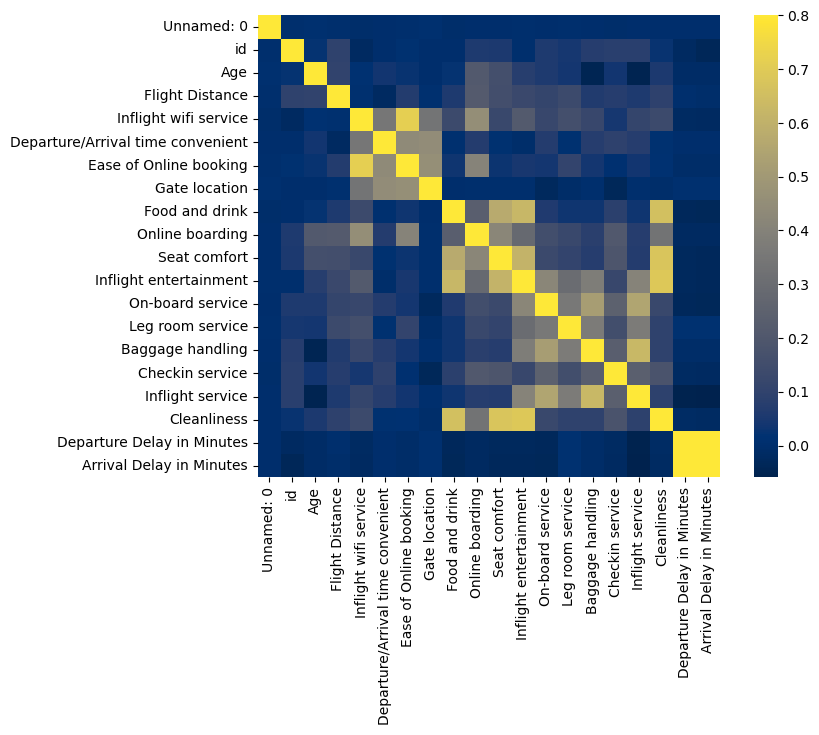

In [14]:
matrix = train_df.corr() 
f, ax = plt.subplots(figsize=(9, 6)) 
sns.heatmap(matrix, vmax=.8, square=True, cmap="cividis");


**Remarque** <br>
- Inflight wifi service et ease of online booking sont fortement corrélées entre elles.
- Departure Delay in minutes et Arrival delay in minutes  sont fortement corrélés entre eux.
- Cleanliness, food and drink, seat comfort and inflight entertainmen sont corrélés à environ 65% entre eux.
- Inflight service, Baggage handling,on-board service sont corrélés à environ 60%.


# Partie II :Prétraitement des données

In [15]:
train_df.head()


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

### vérifier les valeurs en double

In [17]:
train_df.duplicated().sum()

0

### le nombre de valeurs manquantes (NaN)

In [18]:
train_df.isna().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

In [19]:
test_df.isna().sum()

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


### Remplissez les valeurs nulles dans l'ensemble de données d'entraînement et de test

In [20]:
train_df['Arrival Delay in Minutes'].fillna(train_df['Arrival Delay in Minutes'].mode()[0], inplace=True)
###train_df['Arrival Delay in Minutes']=train_df['Arrival Delay in Minutes'].astype(int)

In [21]:
test_df['Arrival Delay in Minutes'].fillna(test_df['Arrival Delay in Minutes'].mode()[0], inplace=True)
##test_df['Arrival Delay in Minutes']=test_df['Arrival Delay in Minutes'].astype(int)

In [22]:
train_df.isna().sum().sum() , test_df.isna().sum().sum()


(0, 0)

In [23]:
train_df.isnull().sum()


Unnamed: 0                           0
id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

### Supprimez les colonnes inutiles

In [24]:
train_df=train_df.drop(['Unnamed: 0', 'id'],axis=1) 
test_df=test_df.drop(['Unnamed: 0', 'id'],axis=1)




In [25]:
train_df.head()


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


### Séparer la variable Target et features

In [26]:
X = train_df.drop('satisfaction',axis=1)
y = train_df.satisfaction


In [27]:
test_X = test_df.drop('satisfaction',axis=1)
test_y = test_df.satisfaction



### Conversion numérique des caractéristiques pour les données catégorielles ( 'Gender', 'Customer Type', 'Type of Travel', 'Class')

In [28]:
testsds = train_df.select_dtypes(include=['object'])
print(testsds.columns)

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')


In [29]:

X = pd.get_dummies(X, columns=['Class'])
test_X = pd.get_dummies(test_X, columns=['Class'])


In [30]:
X.head()

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Business,Class_Eco,Class_Eco Plus
0,Male,Loyal Customer,13,Personal Travel,460,3,4,3,1,5,...,3,4,4,5,5,25,18.0,0,0,1
1,Male,disloyal Customer,25,Business travel,235,3,2,3,3,1,...,5,3,1,4,1,1,6.0,1,0,0
2,Female,Loyal Customer,26,Business travel,1142,2,2,2,2,5,...,3,4,4,4,5,0,0.0,1,0,0
3,Female,Loyal Customer,25,Business travel,562,2,5,5,5,2,...,5,3,1,4,2,11,9.0,1,0,0
4,Male,Loyal Customer,61,Business travel,214,3,3,3,3,4,...,4,4,3,3,3,0,0.0,1,0,0


In [31]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

columns_to_encode = ['Gender', 'Customer Type', 'Type of Travel']

for column in columns_to_encode:
    X[column] = label_encoder.fit_transform(X[column])

X.head()



from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

columns_to_encode = ['Gender', 'Customer Type', 'Type of Travel']

for column in columns_to_encode:
    test_X[column] = label_encoder.fit_transform(test_X[column])


**Remarque** 
- L'objectif est de transformer les données catégorielles en un format numérique adapté à l'entraînement du modèle d'apprentissage automatique  <br>(Gender, Customer Type, Type of Travel, Class) <br>

In [32]:
X.head()

,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_Business,Class_Eco,Class_Eco Plus
0,1,0,13,1,460,3,4,3,1,5,...,3,4,4,5,5,25,18.0,0,0,1
1,1,1,25,0,235,3,2,3,3,1,...,5,3,1,4,1,1,6.0,1,0,0
2,0,0,26,0,1142,2,2,2,2,5,...,3,4,4,4,5,0,0.0,1,0,0
3,0,0,25,0,562,2,5,5,5,2,...,5,3,1,4,2,11,9.0,1,0,0
4,1,0,61,0,214,3,3,3,3,4,...,4,4,3,3,3,0,0.0,1,0,0


### Split l'ensemble de données

In [33]:
x_train, x_val, y_train, y_val = train_test_split(X,y, test_size =0.3)

In [34]:
x_train.shape, x_val.shape , y_train.shape, y_val.shape, test_X.shape ,test_y.shape

((72732, 24), (31172, 24), (72732,), (31172,), (25976, 24), (25976,))

## Modèle avec paramètres par défaut

In [35]:
def defaultpara_model(model):
    model.fit(x_train, y_train)
    pred = model.predict(x_val)
    pred_test = model.predict(test_X)
    
    train_accuracy = model.score(x_train, y_train)
    val_accuracy = accuracy_score(y_val, pred)
    test_accuracy = accuracy_score(test_y, pred_test)
    
    precision = precision_score(y_val, pred, pos_label='satisfied')
    recall = recall_score(y_val, pred, pos_label='satisfied')
    f1 = f1_score(y_val, pred, pos_label='satisfied')

    return train_accuracy, val_accuracy, test_accuracy, precision, recall, f1

### KNN

In [36]:
score = {}
train_score, val_score, test_score, precision, recall, f1 = defaultpara_model(KNeighborsClassifier())
score.update({'KNN': [train_score, val_score, test_score, precision, recall, f1]})


### Random Forest

In [37]:
train_score_r, val_score_r, test_score_r, precision_r, recall_r, f1_r = defaultpara_model(RandomForestClassifier())
score.update({'Random Forest': [train_score_r, val_score_r, test_score_r, precision_r, recall_r, f1_r]})

### Decision Tree

In [38]:
train_score_d, val_score_d, test_score_d, precision_d, recall_d, f1_d = defaultpara_model(DecisionTreeClassifier())
score.update({'Decision Tree': [train_score_d, val_score_d, test_score_d, precision_d, recall_d, f1_d]})

### Resultats :

In [39]:
score_df = pd.DataFrame(score, index=['Train', 'Validation', 'Test', 'Precision', 'Recall', 'F1'])
df_styled = score_df.style.highlight_max(subset=score_df.columns[:], axis=1)
df_styled

,KNN,Random Forest,Decision Tree
Train,0.828095,1.000000,1.000000
Validation,0.744707,0.960092,0.943443
Test,0.739336,0.961503,0.944449
Precision,0.722812,0.970469,0.933790
Recall,0.668906,0.936646,0.936203
F1,0.694815,0.953258,0.934995


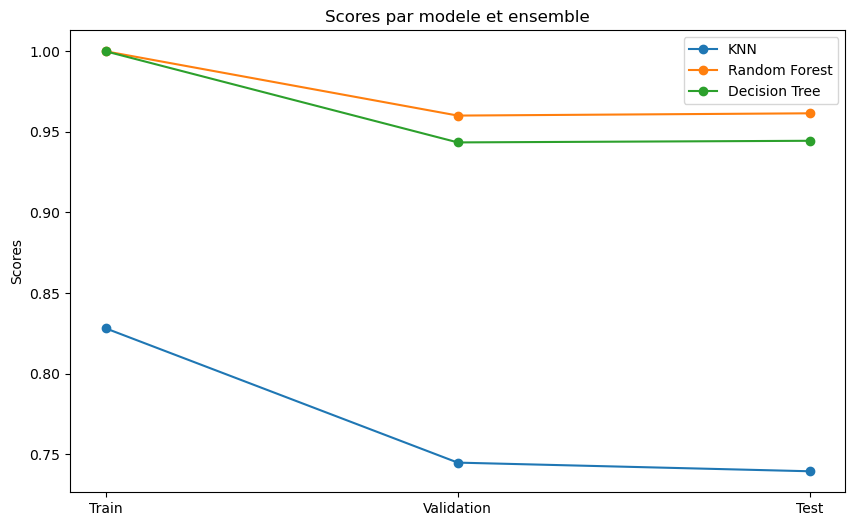

In [40]:
labels = ['Train', 'Validation', 'Test']
models = ['KNN', 'Random Forest', 'Decision Tree']

train_scores = [train_score, train_score_r, train_score_d]
val_scores = [val_score, val_score_r, val_score_d]
test_scores = [test_score, test_score_r, test_score_d]

fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(models):
    ax.plot(labels, [train_scores[i], val_scores[i], test_scores[i]], label=model, marker='o')

ax.set_ylabel('Scores')
ax.set_title('Scores par modele et ensemble')
ax.legend()

plt.show()


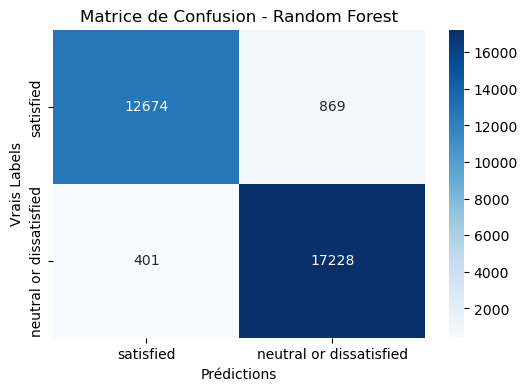

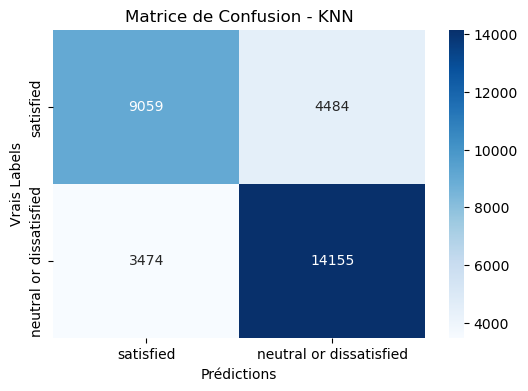

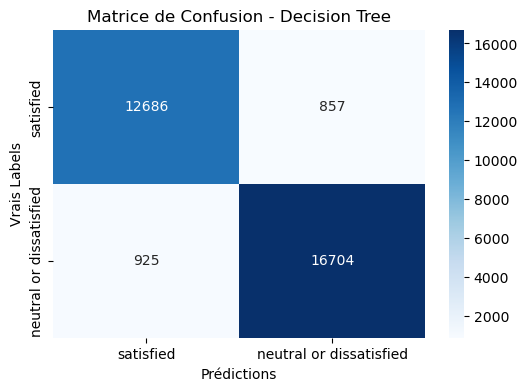

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(model, x_train, y_train, x_val, y_val, model_name):
 
    model.fit(x_train, y_train)
    
    pred_val = model.predict(x_val)
    
    cm = confusion_matrix(y_val, pred_val, labels=['satisfied', 'neutral or dissatisfied'])
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['satisfied', 'neutral or dissatisfied'], 
                yticklabels=['satisfied', 'neutral or dissatisfied'])
    plt.title(f'Matrice de Confusion - {model_name}')
    plt.xlabel('Prédictions')
    plt.ylabel('Vrais Labels')
    plt.show()



rf_model = RandomForestClassifier()
plot_confusion_matrix(rf_model, x_train, y_train, x_val, y_val, 'Random Forest')


knn_model = KNeighborsClassifier()
plot_confusion_matrix(knn_model, x_train, y_train, x_val, y_val, 'KNN')


from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
plot_confusion_matrix(dt_model, x_train, y_train, x_val, y_val, 'Decision Tree')


## Optimisation des hyperparamètres

##### Pour réaliser cette recherche de paramètres, plusieurs options s'offrent à nous dans Scikit-Learn :

- GridSearchCv
- RandomizedSearchCV

### Définir le modèle et ses hyperparamètres pour le réglage des hyperparamètres: KNN

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

model_knn = KNeighborsClassifier()

hyper_para = {'metric': ['euclidean', 'manhattan'],
                  'n_neighbors': [3]}  

dt = DecisionTreeClassifier()


param_dt = {"max_depth": [3],  
            "max_features": [1],  
            "min_samples_split": [2],  
            "criterion": ["gini"]}


#### RandomizedSearchCV

In [42]:
def randomized(model,para,cv=5):
    
    random_search = RandomizedSearchCV(model,param_distributions=para,cv=cv,n_iter=10)
    random_search.fit(x_train,y_train)
    
    pred_val = random_search.predict(x_val)
    pred_y = random_search.predict(test_X)
    
    print(f'train score : {random_search.score(x_train,y_train)} ,\
    \nval score :  {accuracy_score(y_val,pred_val)},\
    \ntest score :  {accuracy_score(test_y,pred_y)}')
    
    return random_search.best_params_

In [43]:
randomized(model_knn,hyper_para)

train score : 0.9038250013749106 ,    
val score :  0.8129411009880663,    
test score :  0.8079765937788728


{'n_neighbors': 3, 'metric': 'manhattan'}

In [44]:
randomized(dt,param_dt)


train score : 0.7760545564538305 ,    
val score :  0.7796740664699089,    
test score :  0.7722128118263012


{'min_samples_split': 2,
 'max_features': 1,
 'max_depth': 3,
 'criterion': 'gini'}

#### GridSearchCV

In [45]:
def gridsearch(model,para,cv=5):
    grid_search = GridSearchCV(model,param_grid=para, cv=cv)
    grid_search.fit(x_train,y_train)
    pred_val = grid_search.predict(x_val)
    pred_y = grid_search.predict(test_X)
    print(f' train score : {grid_search.score(X,y)} , \
    \nval score :  {accuracy_score(y_val,pred_val)}, \
    \ntest score :  {accuracy_score(test_y,pred_y)}')
    
    return grid_search.best_params_

In [46]:
gridsearch(model_knn,hyper_para)

 train score : 0.8765591315060055 ,     
val score :  0.8129411009880663,     
test score :  0.8079765937788728


{'metric': 'manhattan', 'n_neighbors': 3}

## Feature Selection

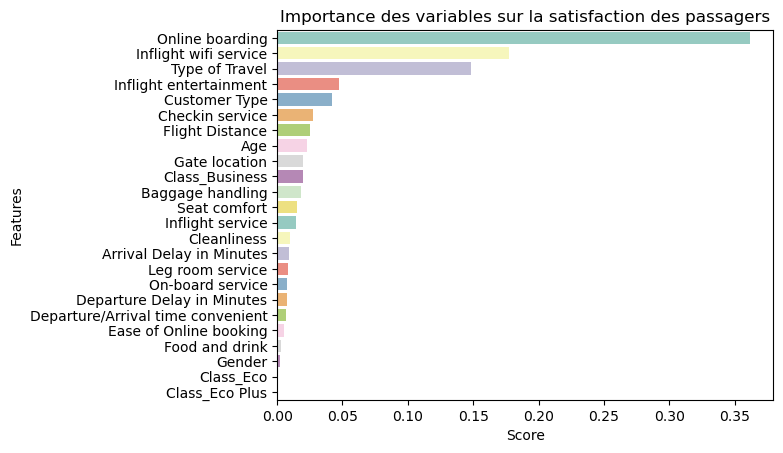

In [47]:
dt = DecisionTreeClassifier()


dt.fit(x_train, y_train)


feature_importance = dt.feature_importances_
feat_imp = pd.DataFrame({'Features': X.columns, 'Score': feature_importance})

feat_imp = feat_imp.sort_values(by='Score', ascending=False)


sns.barplot(x=feat_imp["Score"], y=feat_imp["Features"], palette="Set3")
plt.title("Importance des variables sur la satisfaction des passagers")
plt.show()




**Commentaires :**

Les variables OnlineBoarding, Inflight wifi service, Class, Type of Travel, Inflight entertainment, Seat comfort sont les variables les plus discriminantes. <br>
En revanche, Customer Type, Gate Location, Departure/Arrival Time convenient, Gender et Departure Delay in Minutes n'ont aucun impact sur la satisfaction du client.<br>


## Impact des Caractéristiques sur la Satisfaction des Passagers

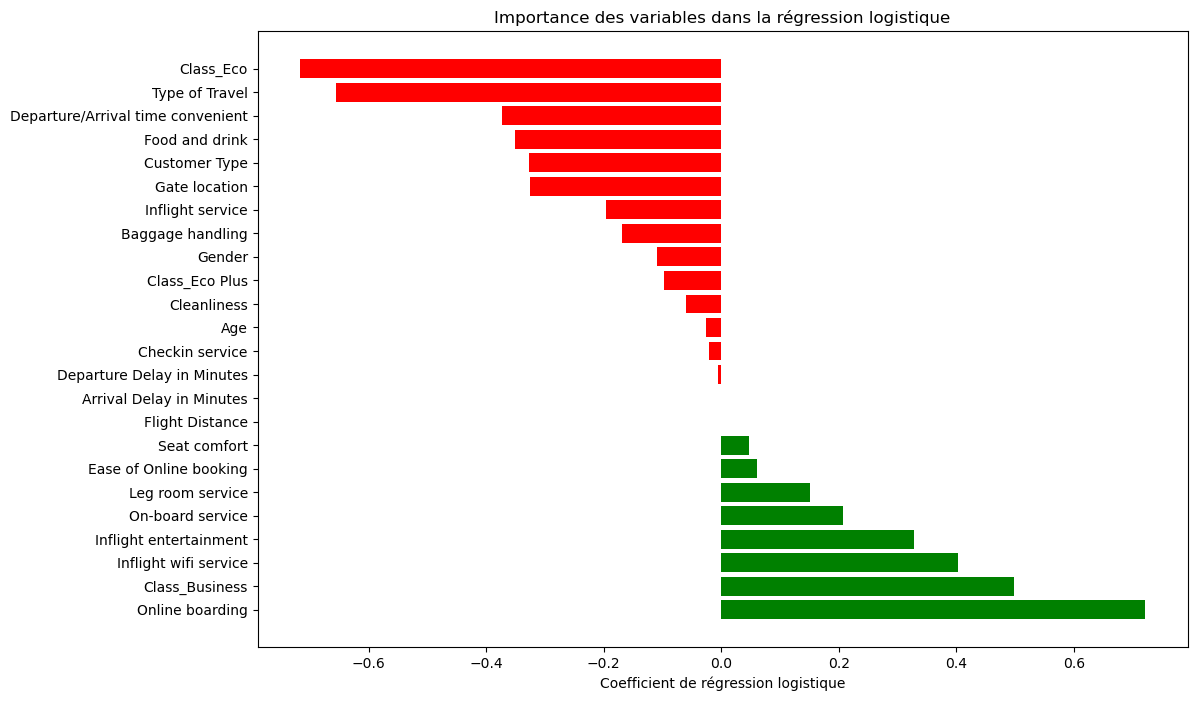

In [48]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train, y_train)

coefficients = log_model.coef_[0]
feature_names = x_train.columns


importance_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})



importance_df = importance_df.sort_values(by="Coefficient", ascending=False)




colors = ['red' if c < 0 else 'green' for c in importance_df["Coefficient"]]



plt.figure(figsize=(12, 8))
plt.barh(importance_df["Feature"], importance_df["Coefficient"], color=colors)
plt.xlabel("Coefficient de régression logistique")
plt.title("Importance des variables dans la régression logistique")
plt.show()


**Commentaires :**

Grâce au modèle de régression logistique, les coefficients positifs ou négatifs indiquent l'impact de chaque caractéristique sur la variable cible. En examinant le graphique, on peut voir que les variables telles que « Heure de départ/arrivée », « classe éco », « emplacement de la porte d'embarquement », « type de voyage », « type de client », « service à bord », « nourriture et boissons ». ", "gestion des bagages" sont les plus discriminantes.<br>
Cela signifie que ces aspects ont un impact sur l'insatisfaction des clients, et par conséquent, des améliorations dans ces domaines pourraient contribuer à augmenter la satisfaction globale des clients.<br>
